# XGBoost Classification

## Objective

The goal of this notebook is to build an XGBoost classification model to predict categorical target values.

XGBoost is an advanced ensemble machine learning algorithm based on gradient boosting. It builds multiple trees sequentially, where each new tree attempts to correct errors made by previous trees.

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
%matplotlib inline

## Loading the Dataset

The dataset is loaded and prepared for classification modeling.

In classification problems, the target variable belongs to predefined categories or classes.



In [3]:
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
print(data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

## Feature Selection

The dataset is separated into:

- Features `X`
  - independent variables used for prediction

- Target `y`
  - categorical output variable to be predicted

This is a supervised classification problem.

In [4]:
X=pd.DataFrame(data.data,columns=data.feature_names)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
y=pd.DataFrame(data.target, columns=['target'])
y.tail()

,target
564,0
565,0
566,0
567,0
568,1


## Exploratory Data Analysis

Basic exploratory analysis is performed to understand:
- dataset structure
- feature names
- data types
- class distribution
- summary statistics
- missing values

This helps identify preprocessing requirements before training the model.


In [6]:
X.shape

(569, 30)

In [7]:
#Distribution of y-variable
y.value_counts()

target
1         357
0         212
Name: count, dtype: int64

In [8]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [10]:
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

## Train-Test Split

The dataset is divided into:
- training data
- testing data

The training dataset is used to train the model, while the testing dataset is used to evaluate model performance on unseen data.

In [11]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [12]:
X_train.shape

(455, 30)

In [13]:
X_test.shape

(114, 30)

## XGBoost Classifier

XGBoost Classifier is a gradient boosting ensemble algorithm.

It combines multiple decision trees sequentially to improve classification performance.

Key advantages:
- high predictive accuracy
- handles complex relationships
- regularization support
- strong performance on structured datasets

In [14]:
model=XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42,
    eval_metrics='logloss'
)

## Model Training

The XGBoost classification model is trained using the training dataset.

During training, the model learns patterns and relationships between input features and target classes.

In [15]:
model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Prediction

The trained XGBoost model is used to predict class labels for the test dataset.

Predicted values are compared with actual values to evaluate model performance.


In [16]:
y_pred=model.predict(X_test)

In [17]:
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

In [18]:
y_test[:10]

,target
532,1
374,1
74,1
333,1
46,1
206,1
107,1
105,0
84,1
367,1


In [19]:
X_test[:10]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
532,13.680,16.33,87.76,575.5,0.09277,0.07255,0.017520,0.018800,0.1631,0.06155,...,15.850,20.20,101.60,773.4,0.1264,0.15640,0.120600,0.08704,0.2806,0.07782
374,13.690,16.07,87.84,579.1,0.08302,0.06374,0.025560,0.020310,0.1872,0.05669,...,14.840,20.21,99.16,670.6,0.1105,0.20960,0.134600,0.06987,0.3323,0.07701
74,12.310,16.52,79.19,470.9,0.09172,0.06829,0.033720,0.022720,0.1720,0.05914,...,14.110,23.21,89.71,611.1,0.1176,0.18430,0.170300,0.08660,0.2618,0.07609
333,11.250,14.78,71.38,390.0,0.08306,0.04458,0.000974,0.002941,0.1773,0.06081,...,12.760,22.06,82.08,492.7,0.1166,0.09794,0.005518,0.01667,0.2815,0.07418
46,8.196,16.84,51.71,201.9,0.08600,0.05943,0.015880,0.005917,0.1769,0.06503,...,8.964,21.96,57.26,242.2,0.1297,0.13570,0.068800,0.02564,0.3105,0.07409
206,9.876,17.27,62.92,295.4,0.10890,0.07232,0.017560,0.019520,0.1934,0.06285,...,10.420,23.22,67.08,331.6,0.1415,0.12470,0.062130,0.05588,0.2989,0.07380
107,12.360,18.54,79.01,466.7,0.08477,0.06815,0.026430,0.019210,0.1602,0.06066,...,13.290,27.49,85.56,544.1,0.1184,0.19630,0.193700,0.08442,0.2983,0.07185
105,13.110,15.56,87.21,530.2,0.13980,0.17650,0.207100,0.096010,0.1925,0.07692,...,16.310,22.40,106.40,827.2,0.1862,0.40990,0.637600,0.19860,0.3147,0.14050
84,12.000,15.65,76.95,443.3,0.09723,0.07165,0.041510,0.018630,0.2079,0.05968,...,13.670,24.90,87.78,567.9,0.1377,0.20030,0.226700,0.07632,0.3379,0.07924
367,12.210,18.02,78.31,458.4,0.09231,0.07175,0.043920,0.020270,0.1695,0.05916,...,14.290,24.04,93.85,624.6,0.1368,0.21700,0.241300,0.08829,0.3218,0.07470


In [20]:
y_pred_prob=model.predict_proba(X_test)

In [21]:
y_pred_prob[:10]

array([[4.3202639e-03, 9.9567974e-01],
       [7.8737736e-04, 9.9921262e-01],
       [2.2346973e-03, 9.9776530e-01],
       [1.9053817e-03, 9.9809462e-01],
       [1.1019707e-03, 9.9889803e-01],
       [1.1031628e-03, 9.9889684e-01],
       [7.9932809e-03, 9.9200672e-01],
       [9.4640034e-01, 5.3599630e-02],
       [2.1271706e-03, 9.9787283e-01],
       [2.6122928e-03, 9.9738771e-01]], dtype=float32)

In [22]:
y_pred_prob[:10].tolist()

[[0.004320263862609863, 0.9956797361373901],
 [0.0007873773574829102, 0.9992126226425171],
 [0.0022346973419189453, 0.997765302658081],
 [0.0019053816795349121, 0.9980946183204651],
 [0.0011019706726074219, 0.9988980293273926],
 [0.0011031627655029297, 0.9988968372344971],
 [0.00799328088760376, 0.9920067191123962],
 [0.9464003443717957, 0.053599629551172256],
 [0.0021271705627441406, 0.9978728294372559],
 [0.002612292766571045, 0.997387707233429]]

In [23]:
y_proba = model.predict_proba(X_test)[:, 1]

In [24]:
y_proba[:10].tolist()

[0.9956797361373901,
 0.9992126226425171,
 0.997765302658081,
 0.9980946183204651,
 0.9988980293273926,
 0.9988968372344971,
 0.9920067191123962,
 0.053599629551172256,
 0.9978728294372559,
 0.997387707233429]

## Model Evaluation

Classification models are evaluated using:
- Accuracy Score
- Confusion Matrix
- Precision
- Recall
- F1-Score

These metrics help measure classification performance and prediction quality.


In [25]:
accuracy_score(y_test,y_pred)

0.9824561403508771

In [26]:
precision_score(y_test,y_pred)

0.972972972972973

In [27]:
recall_score(y_test,y_pred)

1.0

In [28]:
f1_score(y_test,y_pred)

0.9863013698630136

In [29]:
roc_auc_score(y_test,y_proba)

0.9983465608465608

In [30]:
confusion_matrix(y_test,y_pred)

array([[40,  2],
       [ 0, 72]])

In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



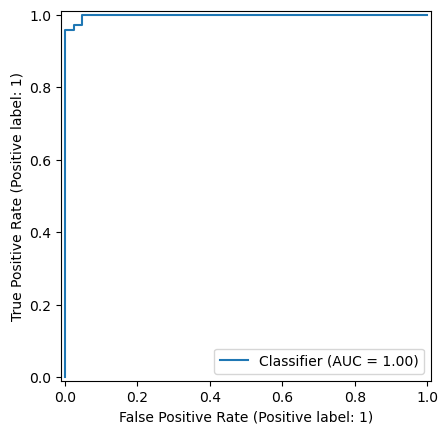

In [32]:
RocCurveDisplay.from_predictions(y_test,y_proba)
plt.show()

## Feature Importance

Feature importance helps identify which variables contributed most to the classification predictions.

This improves model interpretability and helps understand influential features.

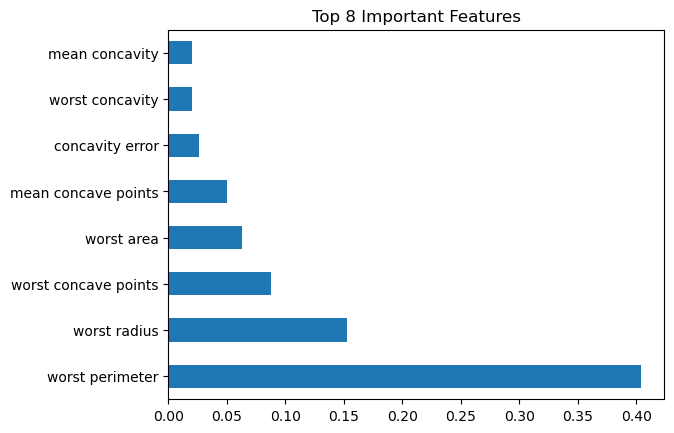

In [33]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(8).plot(kind='barh')
plt.title("Top 8 Important Features")
plt.show()

In [34]:
import warnings
warnings.filterwarnings('ignore')

## Hyperparameter Tuning using GridSearchCV

GridSearchCV is used to identify the best hyperparameter combination for the XGBoost classifier.

The tuning process improves model performance by testing multiple parameter combinations using cross-validation.

Parameters tuned include:
- learning rate
- number of estimators
- maximum depth
- subsample ratio
- feature sampling ratio

In [35]:
param_grid={
    'learning_rate':[0.01, 0.05, 0.1 ,0.5],
    'n_estimators':[50, 100, 150, 200, 300],
    'max_depth':[3,4,5],
    'subsample':[0.6, 0.8,1.0],
    'colsample_bytree':[0.6, 0.8,1.0]
}

In [36]:
grid=GridSearchCV(
    estimator=XGBClassifier(eval_metrics='logloss'),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1 #number of jobs in parllel -1 use all processors
)

In [37]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 540 candidates, totalling 1620 fits


,estimator,"XGBClassifier...obs=None, ...)"
,param_grid,"{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [38]:
grid.best_params_

{'colsample_bytree': 0.6,
 'learning_rate': 0.05,
 'max_depth': 5,
 'n_estimators': 200,
 'subsample': 0.6}

In [39]:
best_model=grid.best_estimator_
y_pred=best_model.predict(X_test)
y_proba=best_model.predict_proba(X_test)[:,1]

In [40]:
y_pred


array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1])

In [41]:
y_proba.tolist()[:5]

[0.9961363673210144,
 0.9991205334663391,
 0.9992409944534302,
 0.9977819323539734,
 0.9989157915115356]

In [42]:
#Final ROC-AUC
roc_auc_score(y_test,y_proba)

0.9996693121693121

## Conclusion

The XGBoost Classifier was successfully implemented for classification prediction.

Key learnings from this notebook:
- understanding gradient boosting workflow
- implementing XGBoost classification
- evaluating classification performance
- hyperparameter tuning using GridSearchCV
- interpreting feature importance

This notebook demonstrates a complete end-to-end classification workflow using XGBoost.